In [1]:
import pandas as pd

# Define the path to the dataset

df = pd.read_csv('/kaggle/input/social-anxiety-dataset/enhanced_anxiety_dataset.csv')

In [2]:
# Check data types and non-null counts
df.info()

# Summary statistics for numeric columns
df.describe()

# Check missing values per column
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11000 entries, 0 to 10999
Data columns (total 19 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                11000 non-null  int64  
 1   Gender                             11000 non-null  object 
 2   Occupation                         11000 non-null  object 
 3   Sleep Hours                        11000 non-null  float64
 4   Physical Activity (hrs/week)       11000 non-null  float64
 5   Caffeine Intake (mg/day)           11000 non-null  int64  
 6   Alcohol Consumption (drinks/week)  11000 non-null  int64  
 7   Smoking                            11000 non-null  object 
 8   Family History of Anxiety          11000 non-null  object 
 9   Stress Level (1-10)                11000 non-null  int64  
 10  Heart Rate (bpm)                   11000 non-null  int64  
 11  Breathing Rate (breaths/min)       11000 non-null  int

Age                                  0
Gender                               0
Occupation                           0
Sleep Hours                          0
Physical Activity (hrs/week)         0
Caffeine Intake (mg/day)             0
Alcohol Consumption (drinks/week)    0
Smoking                              0
Family History of Anxiety            0
Stress Level (1-10)                  0
Heart Rate (bpm)                     0
Breathing Rate (breaths/min)         0
Sweating Level (1-5)                 0
Dizziness                            0
Medication                           0
Therapy Sessions (per month)         0
Recent Major Life Event              0
Diet Quality (1-10)                  0
Anxiety Level (1-10)                 0
dtype: int64

In [3]:
df.head(20)

,Age,Gender,Occupation,Sleep Hours,Physical Activity (hrs/week),Caffeine Intake (mg/day),Alcohol Consumption (drinks/week),Smoking,Family History of Anxiety,Stress Level (1-10),Heart Rate (bpm),Breathing Rate (breaths/min),Sweating Level (1-5),Dizziness,Medication,Therapy Sessions (per month),Recent Major Life Event,Diet Quality (1-10),Anxiety Level (1-10)
0,29,Female,Artist,6.0,2.7,181,10,Yes,No,10,114,14,4,No,Yes,3,Yes,7,5.0
1,46,Other,Nurse,6.2,5.7,200,8,Yes,Yes,1,62,23,2,Yes,No,2,No,8,3.0
2,64,Male,Other,5.0,3.7,117,4,No,Yes,1,91,28,3,No,No,1,Yes,1,1.0
3,20,Female,Scientist,5.8,2.8,360,6,Yes,No,4,86,17,3,No,No,0,No,1,2.0
4,49,Female,Other,8.2,2.3,247,4,Yes,No,1,98,19,4,Yes,Yes,1,No,3,1.0
5,53,Male,Other,6.4,6.5,235,2,No,No,9,84,14,3,No,Yes,2,Yes,5,4.0
6,20,Male,Artist,7.9,2.5,78,14,Yes,No,8,118,21,5,Yes,No,1,Yes,2,4.0
7,54,Female,Lawyer,6.3,5.5,535,15,No,No,5,113,19,1,No,No,0,No,7,4.0
8,51,Other,Lawyer,6.6,3.1,587,2,No,No,2,81,22,1,Yes,No,2,Yes,8,3.0
9,59,Female,Teacher,5.1,4.8,159,15,Yes,No,5,95,28,5,Yes,Yes,1,Yes,1,4.0


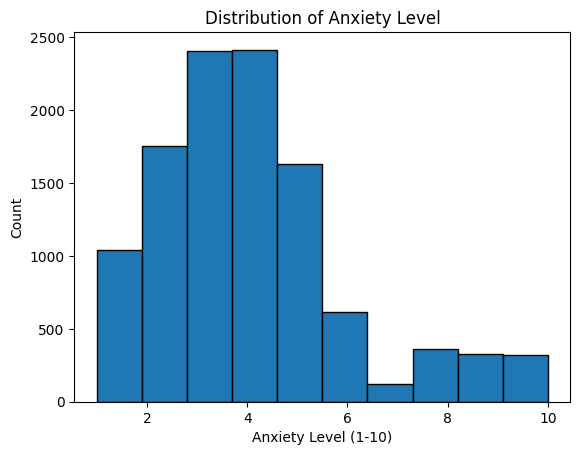

In [4]:
# Histogram to see Anxiety Level distribution
import matplotlib.pyplot as plt

plt.hist(df["Anxiety Level (1-10)"], bins=10, edgecolor='black')
plt.xlabel("Anxiety Level (1-10)")
plt.ylabel("Count")
plt.title("Distribution of Anxiety Level")
plt.show()

# If it's discrete with peaks, we might consider binning it for classification later.


Anxiety Level (1-10)                 1.000000
Stress Level (1-10)                  0.667939
Therapy Sessions (per month)         0.517606
Caffeine Intake (mg/day)             0.350651
Heart Rate (bpm)                     0.188900
Sweating Level (1-5)                 0.160074
Breathing Rate (breaths/min)         0.157048
Alcohol Consumption (drinks/week)    0.100626
Age                                 -0.074316
Diet Quality (1-10)                 -0.220245
Physical Activity (hrs/week)        -0.243187
Sleep Hours                         -0.493836
Name: Anxiety Level (1-10), dtype: float64


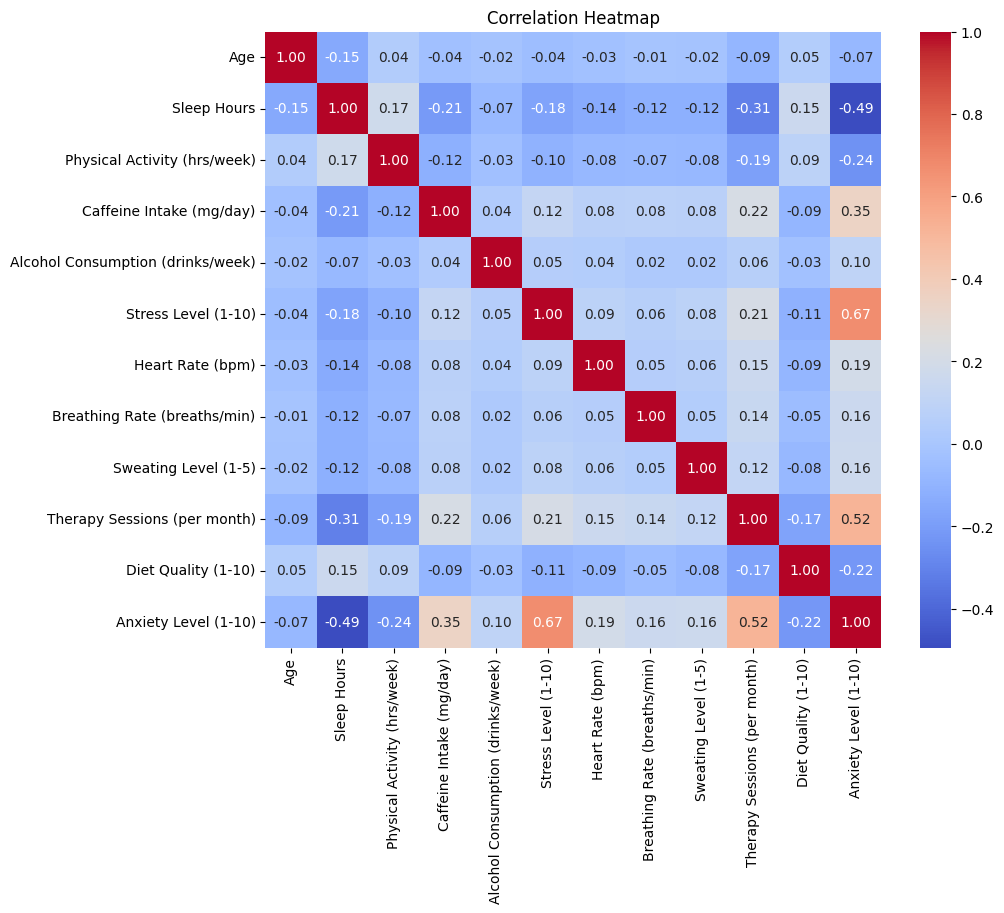

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select numeric columns only
numeric_cols = [
    'Age', 'Sleep Hours', 'Physical Activity (hrs/week)', 
    'Caffeine Intake (mg/day)', 'Alcohol Consumption (drinks/week)', 
    'Stress Level (1-10)', 'Heart Rate (bpm)', 'Breathing Rate (breaths/min)',
    'Sweating Level (1-5)', 'Therapy Sessions (per month)', 
    'Diet Quality (1-10)', 'Anxiety Level (1-10)'
]

# Correlation matrix
correlation_matrix = df[numeric_cols].corr()

# Show correlation with Anxiety Level
anxiety_corr = correlation_matrix['Anxiety Level (1-10)'].sort_values(ascending=False)
print(anxiety_corr)

# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Heatmap")
plt.show()


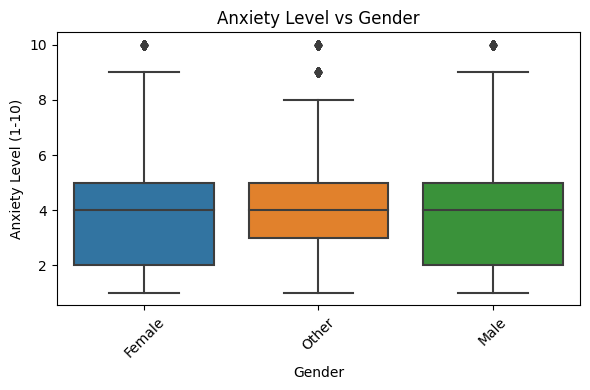

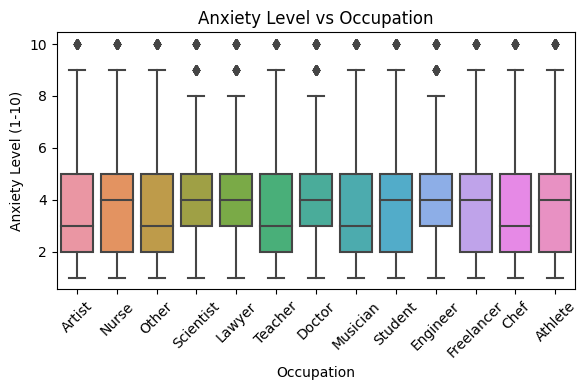

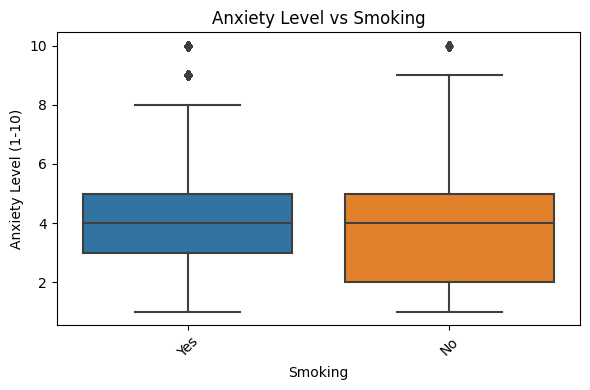

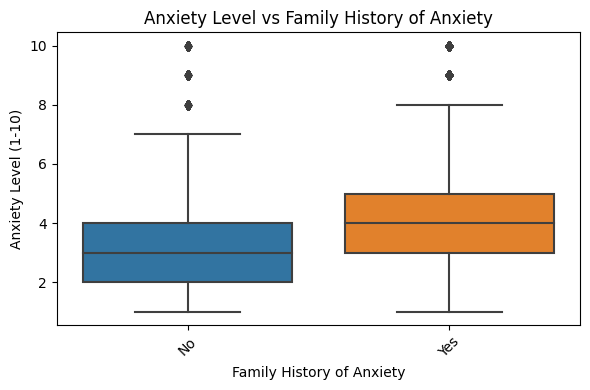

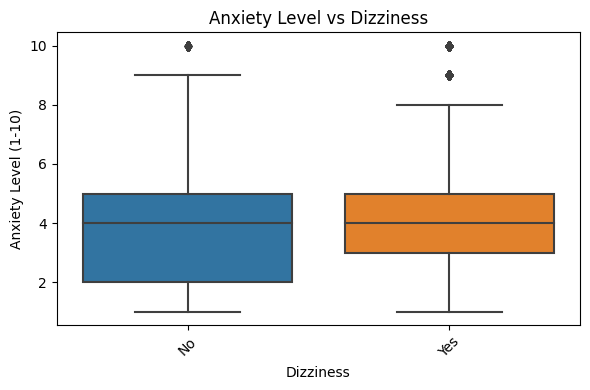

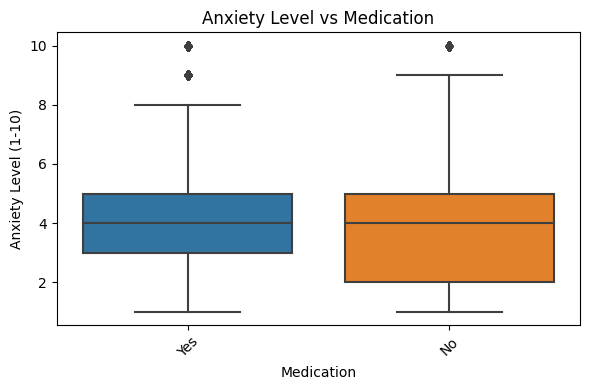

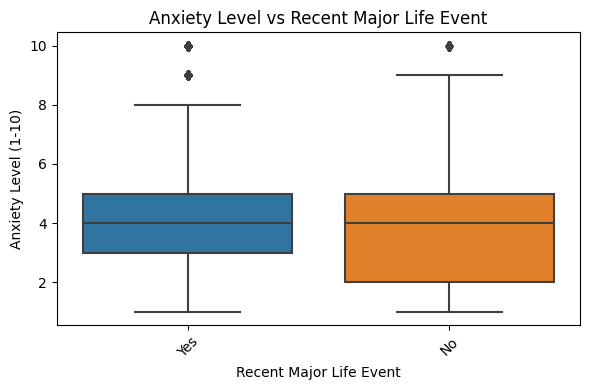

In [6]:
categorical_features = [
    'Gender', 'Occupation', 'Smoking', 'Family History of Anxiety', 
    'Dizziness', 'Medication', 'Recent Major Life Event'
]

for col in categorical_features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[col], y=df['Anxiety Level (1-10)'])
    plt.title(f'Anxiety Level vs {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


In [7]:
for col in categorical_features:
    print(f"\nMean Anxiety Level by {col}:")
    print(df.groupby(col)['Anxiety Level (1-10)'].mean().sort_values(ascending=False))



Mean Anxiety Level by Gender:
Gender
Male      3.933552
Female    3.931367
Other     3.923056
Name: Anxiety Level (1-10), dtype: float64

Mean Anxiety Level by Occupation:
Occupation
Lawyer        4.206428
Doctor        4.199525
Engineer      4.138055
Scientist     4.062500
Freelancer    3.952267
Student       3.883827
Athlete       3.871046
Nurse         3.854820
Chef          3.840326
Artist        3.796171
Musician      3.789238
Other         3.764286
Teacher       3.749690
Name: Anxiety Level (1-10), dtype: float64

Mean Anxiety Level by Smoking:
Smoking
Yes    4.09448
No     3.74660
Name: Anxiety Level (1-10), dtype: float64

Mean Anxiety Level by Family History of Anxiety:
Family History of Anxiety
Yes    4.309731
No     3.497768
Name: Anxiety Level (1-10), dtype: float64

Mean Anxiety Level by Dizziness:
Dizziness
Yes    4.120769
No     3.725601
Name: Anxiety Level (1-10), dtype: float64

Mean Anxiety Level by Medication:
Medication
Yes    4.045711
No     3.805774
Name: Anxiety

There are not obvius relationship from means 

Correlation Insights (Numeric Features)
Strong Positive Correlations:

Stress Level (1-10) (+0.67) – most strongly linked to anxiety.

Therapy Sessions (per month) (+0.52) – high anxiety leads to more therapy.

Caffeine Intake (mg/day) (+0.35) – possibly stimulating anxiety.

Strong Negative Correlations:

Sleep Hours (−0.49) – less sleep linked to more anxiety.

Physical Activity (hrs/week) (−0.24) – active people report less anxiety.

Diet Quality (1-10) (−0.22) – better diet helps mitigate anxiety.

Categorical Factors (Boxplot Findings)
Family History of Anxiety and Dizziness showed meaningful differences in anxiety levels.

Other categorical factors (Gender, Occupation, Smoking, etc.) had weaker visual relationships

In [8]:
#Variable adjusting
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Convert Yes/No binary columns to 1/0
binary_cols = [
    'Smoking', 'Family History of Anxiety', 'Dizziness',
    'Medication', 'Recent Major Life Event'
]
df[binary_cols] = df[binary_cols].replace({'Yes': 1, 'No': 0})

# 2. One-hot encode categorical variables (drop_first=True avoids dummy variable trap)
df = pd.get_dummies(df, columns=['Gender', 'Occupation'], drop_first=True)

# 3. Define features and target
X = df.drop(columns=['Anxiety Level (1-10)'])
y = df['Anxiety Level (1-10)']

# 4. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 5. Scale features (for models that need scaling)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Optional: Convert scaled back to DataFrame with column names
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)



/tmp/ipykernel_13/1631914451.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[binary_cols] = df[binary_cols].replace({'Yes': 1, 'No': 0})


In [9]:
# Convert all boolean columns to int type
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

In [10]:
pip install xgboost catboost scikit-learn pandas matplotlib seaborn


Note: you may need to restart the kernel to use updated packages.



📊 Model Performance Summary
          Model  R2 Score      RMSE
8       Stacked  0.780636  1.008197
5  RandomForest  0.775879  1.019071
7      CatBoost  0.775093  1.020857
6       XGBoost  0.752940  1.069951
3           SVR  0.752296  1.071346
2         Ridge  0.726420  1.125914
0        Linear  0.726416  1.125921
1         Lasso  0.709988  1.159233
4           KNN  0.677186  1.223036

🔗 Correlation Between Model Predictions
              Linear  Lasso  Ridge   SVR   KNN  RandomForest  XGBoost  \
Linear          1.00   0.99   1.00  0.96  0.86          0.95     0.94   
Lasso           0.99   1.00   0.99  0.96  0.84          0.94     0.93   
Ridge           1.00   0.99   1.00  0.96  0.86          0.95     0.94   
SVR             0.96   0.96   0.96  1.00  0.91          0.97     0.96   
KNN             0.86   0.84   0.86  0.91  1.00          0.91     0.90   
RandomForest    0.95   0.94   0.95  0.97  0.91          1.00     0.98   
XGBoost         0.94   0.93   0.94  0.96  0.90          0.9

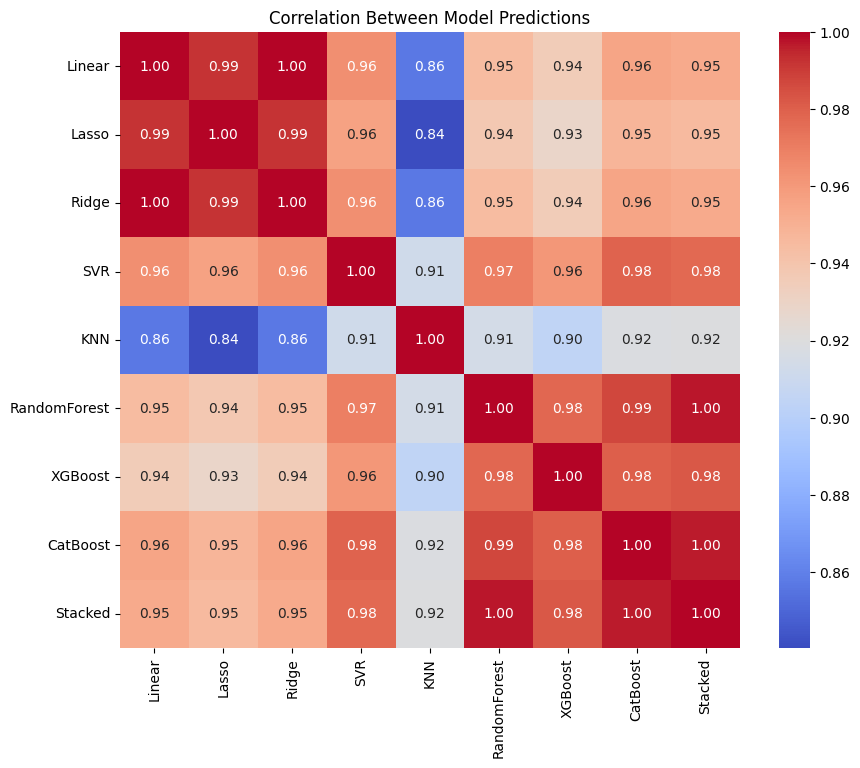

In [11]:
#Model building
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Store models and predictions
models = {
    "Linear": LinearRegression(),
    "Lasso": Lasso(alpha=0.1),
    "Ridge": Ridge(alpha=1.0),
    "SVR": SVR(),
    "KNN": KNeighborsRegressor(),
    "RandomForest": RandomForestRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42),
    "CatBoost": CatBoostRegressor(verbose=0, random_state=42)
}

results = []
predictions_df = pd.DataFrame(index=y_test.index)

# Train and evaluate each model
for name, model in models.items():
    # Use scaled inputs for models that require it
    if name in ["Linear", "Lasso", "Ridge", "SVR", "KNN"]:
        model.fit(X_train_scaled_df, y_train)
        preds = model.predict(X_test_scaled_df)
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

    predictions_df[name] = preds
    r2 = r2_score(y_test, preds)
    rmse = mean_squared_error(y_test, preds, squared=False)
    results.append({"Model": name, "R2 Score": r2, "RMSE": rmse})

# Add Stacking Regressor (uses strongest base models)
stack = StackingRegressor(
    estimators=[
        ('rf', RandomForestRegressor(random_state=42)),
        ('xgb', XGBRegressor(random_state=42)),
        ('cat', CatBoostRegressor(verbose=0, random_state=42))
    ],
    final_estimator=LinearRegression()
)
stack.fit(X_train, y_train)
stack_preds = stack.predict(X_test)
predictions_df["Stacked"] = stack_preds

results.append({
    "Model": "Stacked",
    "R2 Score": r2_score(y_test, stack_preds),
    "RMSE": mean_squared_error(y_test, stack_preds, squared=False)
})

# Create and display summary table
results_df = pd.DataFrame(results).sort_values("R2 Score", ascending=False)
print("\n📊 Model Performance Summary")
print(results_df)

# Correlation between model predictions
print("\n🔗 Correlation Between Model Predictions")
correlation_matrix = predictions_df.corr()
print(correlation_matrix.round(2))

# Optional: visualize heatmap of prediction correlations
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Between Model Predictions")
plt.show()


Decided rto use catboost for better interpretation and for its robustness

In [12]:
import optuna
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, r2_score

# Define the objective function
def objective(trial):
    params = {
        "iterations": trial.suggest_categorical("iterations", [300, 500, 800]),
        "depth": trial.suggest_categorical("depth", [4, 6, 8]),
        "learning_rate": trial.suggest_categorical("learning_rate", [0.01, 0.03, 0.1]),
        "l2_leaf_reg": trial.suggest_categorical("l2_leaf_reg", [1, 3, 5, 7]),
        "bagging_temperature": trial.suggest_categorical("bagging_temperature", [0.5, 1.0, 2.0]),
        "random_strength": 1,
        "rsm": 1,
        "loss_function": "RMSE",
        "verbose": 0,
        "random_state": 42
    }

    model = CatBoostRegressor(**params)
    
    # Cross-validation
    scores = cross_val_score(
        model, X_train, y_train,
        scoring=make_scorer(r2_score),
        cv=5,
        n_jobs=-1
    )
    return scores.mean()

# Run the optimization
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30, show_progress_bar=True)


[I 2025-05-13 15:08:02,521] A new study created in memory with name: no-name-54021f4d-745a-4d84-a528-29676739db41


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2025-05-13 15:08:11,933] Trial 0 finished with value: 0.7576709161578314 and parameters: {'iterations': 500, 'depth': 6, 'learning_rate': 0.1, 'l2_leaf_reg': 3, 'bagging_temperature': 0.5}. Best is trial 0 with value: 0.7576709161578314.
[I 2025-05-13 15:08:29,212] Trial 1 finished with value: 0.764954877884274 and parameters: {'iterations': 800, 'depth': 8, 'learning_rate': 0.03, 'l2_leaf_reg': 3, 'bagging_temperature': 0.5}. Best is trial 1 with value: 0.764954877884274.
[I 2025-05-13 15:08:47,147] Trial 2 finished with value: 0.7499613988047309 and parameters: {'iterations': 800, 'depth': 8, 'learning_rate': 0.1, 'l2_leaf_reg': 7, 'bagging_temperature': 0.5}. Best is trial 1 with value: 0.764954877884274.
[I 2025-05-13 15:08:49,449] Trial 3 finished with value: 0.7640597001094274 and parameters: {'iterations': 300, 'depth': 4, 'learning_rate': 0.03, 'l2_leaf_reg': 3, 'bagging_temperature': 2.0}. Best is trial 1 with value: 0.764954877884274.
[I 2025-05-13 15:09:08,663] Trial 4 fi

In [13]:
# Show best hyperparameters
print("🎯 Best R2 Score from CV:", study.best_value)
print("✅ Best Hyperparameters:")
for k, v in study.best_params.items():
    print(f"{k}: {v}")

# Train final CatBoost model with best params
final_model = CatBoostRegressor(
    **study.best_params,
    loss_function="RMSE",
    random_state=42,
    verbose=0
)
final_model.fit(X_train, y_train)

# Evaluate on test set
from sklearn.metrics import r2_score, mean_squared_error

preds = final_model.predict(X_test)
print("\n📈 Final Model Test Performance:")
print("R2 Score:", round(r2_score(y_test, preds), 4))
print("RMSE:", round(mean_squared_error(y_test, preds, squared=False), 4))


🎯 Best R2 Score from CV: 0.7698690991408963
✅ Best Hyperparameters:
iterations: 800
depth: 8
learning_rate: 0.01
l2_leaf_reg: 7
bagging_temperature: 1.0

📈 Final Model Test Performance:
R2 Score: 0.7852
RMSE: 0.9977


In [14]:
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error,
    median_absolute_error,
    explained_variance_score,
    mean_absolute_percentage_error
)

# Predict on test set
preds = final_model.predict(X_test)

# Evaluate using multiple metrics
r2 = r2_score(y_test, preds)
rmse = mean_squared_error(y_test, preds, squared=False)
mae = mean_absolute_error(y_test, preds)
medae = median_absolute_error(y_test, preds)
evs = explained_variance_score(y_test, preds)
mape = mean_absolute_percentage_error(y_test, preds)

# Display results
print("\n📈 Final Model Test Performance:")
print(f"R² Score:                    {r2:.4f}")
print(f"RMSE (Root Mean Squared):   {rmse:.4f}")
print(f"MAE (Mean Absolute Error):  {mae:.4f}")
print(f"MedAE (Median Abs Error):   {medae:.4f}")
print(f"MAPE (%):                   {mape * 100:.2f}%")
print(f"Explained Variance Score:   {evs:.4f}")



📈 Final Model Test Performance:
R² Score:                    0.7852
RMSE (Root Mean Squared):   0.9977
MAE (Mean Absolute Error):  0.8064
MedAE (Median Abs Error):   0.7228
MAPE (%):                   30.35%
Explained Variance Score:   0.7854


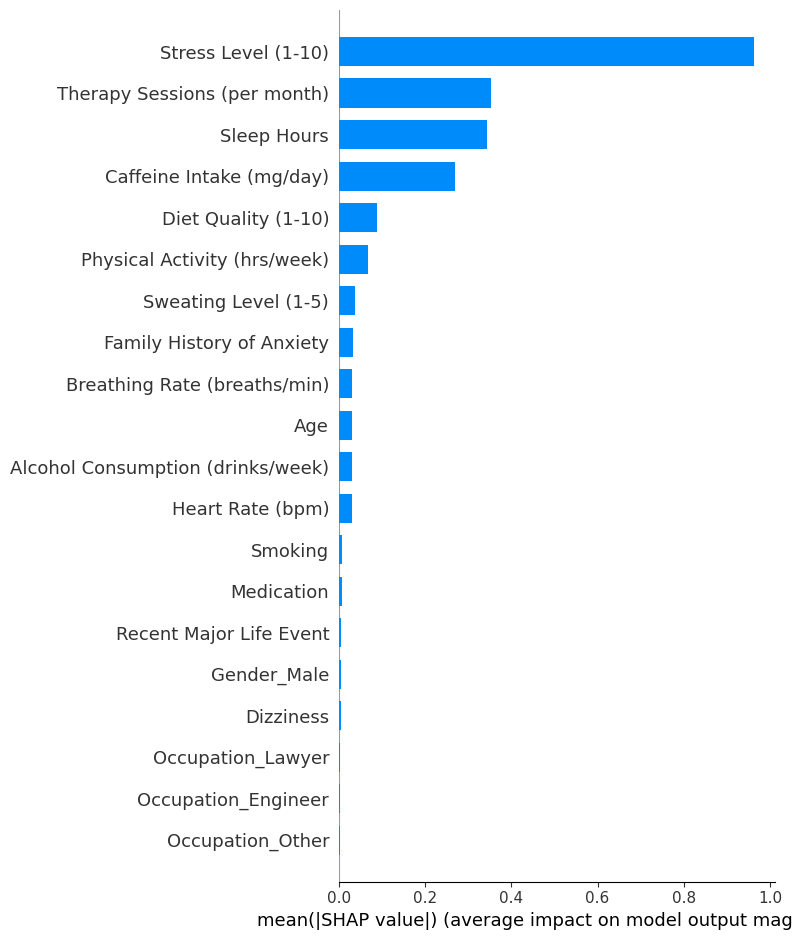

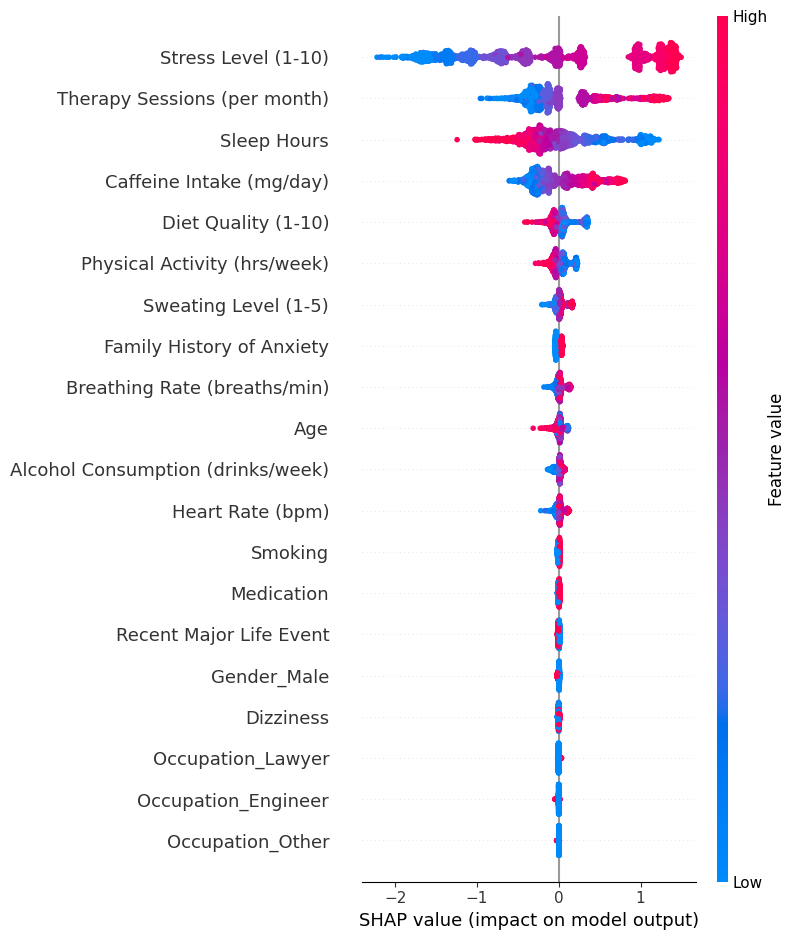

In [15]:
#Shap 
import shap

# Use TreeExplainer for CatBoost
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test)

# Global feature importance summary (bar)
shap.summary_plot(shap_values, X_test, plot_type="bar")

# Global summary with distribution
shap.summary_plot(shap_values, X_test)


In [16]:
# SHAP values as a DataFrame (same shape as X_test)
shap_df = pd.DataFrame(shap_values, columns=X_test.columns, index=X_test.index)

# Optionally add the model predictions and true values
shap_df['Prediction'] = final_model.predict(X_test)
shap_df['True Value'] = y_test
shap_df['Residual'] = shap_df['True Value'] - shap_df['Prediction']


In [17]:
shap_df.drop(columns=['Prediction', 'True Value', 'Residual']).abs().mean().sort_values(ascending=False)


Stress Level (1-10)                  0.962988
Therapy Sessions (per month)         0.353578
Sleep Hours                          0.342993
Caffeine Intake (mg/day)             0.268559
Diet Quality (1-10)                  0.088113
Physical Activity (hrs/week)         0.067725
Sweating Level (1-5)                 0.036329
Family History of Anxiety            0.033130
Breathing Rate (breaths/min)         0.030845
Age                                  0.030542
Alcohol Consumption (drinks/week)    0.030190
Heart Rate (bpm)                     0.029351
Smoking                              0.008199
Medication                           0.006394
Recent Major Life Event              0.006087
Gender_Male                          0.005691
Dizziness                            0.004074
Occupation_Lawyer                    0.002402
Occupation_Engineer                  0.002068
Occupation_Other                     0.001839
Gender_Other                         0.001729
Occupation_Freelancer             

In [18]:
shap_df.loc[shap_df['Prediction'].idxmax()]  # highest predicted anxiety
shap_df.loc[shap_df['Prediction'].idxmin()]  # lowest predicted anxiety


Age                                 -0.019047
Sleep Hours                         -0.603349
Physical Activity (hrs/week)        -0.006908
Caffeine Intake (mg/day)            -0.225122
Alcohol Consumption (drinks/week)   -0.004188
Smoking                              0.006128
Family History of Anxiety           -0.028594
Stress Level (1-10)                 -1.444170
Heart Rate (bpm)                     0.015286
Breathing Rate (breaths/min)        -0.011934
Sweating Level (1-5)                -0.004594
Dizziness                           -0.001344
Medication                           0.004166
Therapy Sessions (per month)        -0.200608
Recent Major Life Event              0.003074
Diet Quality (1-10)                 -0.055261
Gender_Male                         -0.003909
Gender_Other                        -0.001006
Occupation_Athlete                  -0.000361
Occupation_Chef                     -0.000226
Occupation_Doctor                   -0.000948
Occupation_Engineer               

In [19]:
shap_df.to_csv("shap_explanations.csv")


In [20]:
grouped_means = {
    'Lifestyle': shap_df[['Sleep Hours', 'Physical Activity (hrs/week)', 'Caffeine Intake (mg/day)', 'Alcohol Consumption (drinks/week)', 'Diet Quality (1-10)']].abs().mean().sum(),
    'Health': shap_df[['Heart Rate (bpm)', 'Breathing Rate (breaths/min)', 'Sweating Level (1-5)', 'Dizziness']].abs().mean().sum(),
    'Mental History': shap_df[['Family History of Anxiety', 'Therapy Sessions (per month)', 'Medication']].abs().mean().sum(),
    'Demographics': shap_df[['Age'] + [c for c in X_test.columns if 'Gender_' in c or 'Occupation_' in c]].abs().mean().sum()
}
pd.Series(grouped_means).sort_values(ascending=False)


Lifestyle         0.797580
Mental History    0.393102
Health            0.100599
Demographics      0.052520
dtype: float64

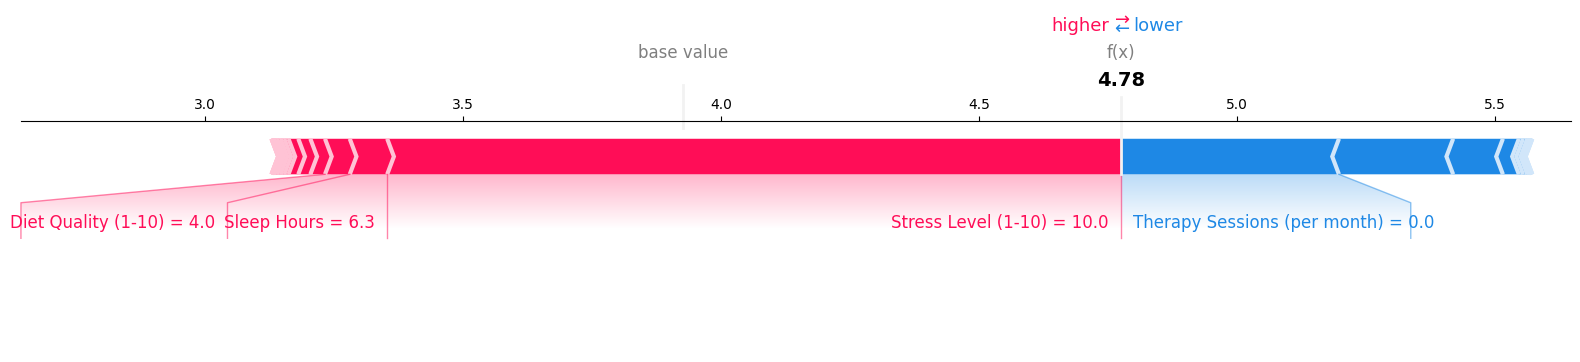

In [21]:
# Visual explanation for one individual prediction
# You can change sample_index to check other variables
sample_index = 1  # change to any index of X_test
shap.force_plot(
    explainer.expected_value, 
    shap_values[sample_index], 
    X_test.iloc[sample_index], 
    matplotlib=True
)


This model was trained to predict social anxiety levels based on behavioral, lifestyle, physiological, and psychological features. The model identifies which features are most predictive of higher or lower anxiety scores, with stress level, sleep hours, therapy frequency, and caffeine intake emerging as the most impactful factors.

However, it's crucial to understand that this is not a causal model. While the model may reveal strong statistical associations, it cannot determine what causes anxiety. For example, frequent therapy sessions may correlate with higher anxiety, but that doesn’t mean therapy increases anxiety — it likely reflects individuals seeking help when anxiety is already high.

That said, the model can still be useful for diagnostic support or early detection. It can flag individuals who, based on their data, are likely to experience higher anxiety and may benefit from proactive interventions.

This project is shared as part of a self-improvement journey — a personal exploration of machine learning applied to meaningful, real-world challenges. It is intended for educational and research purposes only, and not as a tool for clinical diagnosis or medical advice.